<a href="https://colab.research.google.com/github/dlstjs6931/milswai/blob/main/%EB%82%B4%EA%B3%A0%ED%96%A5_vs_%EB%B6%80%EB%8C%80%EC%A3%BC%EB%91%94%EC%A7%80_%EB%B9%84%EA%B5%90%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# STEP 0: 한글 폰트 & 라이브러리 설정

!apt-get install -y fonts-nanum > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 환경 설정 완료!")

✅ 환경 설정 완료!


In [9]:
# STEP 1: Google Drive 연결

from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive 연결 완료!")

Mounted at /content/drive
✅ Google Drive 연결 완료!


In [10]:
# STEP 2: 파일 불러오기 → DataFrame 변환

FOLDER = '/content/drive/MyDrive/Colab Notebooks/지역비교분석/'

files = {
    '인구':    FOLDER + '주민등록인구_시도_시_군_구__20260428161922.csv',
    '약국':    FOLDER + '건강_약국.csv',
    '범죄':    FOLDER + '경찰청_범죄 발생 지역별 통계_20241231.csv',
    '문화시설': FOLDER + 'CI_CLTUR_ART_PHSTRN_SPND_SIGNGU_ACCTO_FCLTY_CO_202302.csv',
    '음식점':  FOLDER + '식품_일반음식점.csv',
}

def load_file(path):
    for enc in ['utf-8', 'cp949', 'euc-kr']:
        try:
            df = pd.read_csv(path, encoding=enc)
            return df
        except:
            continue
    return None

dfs = {}
for label, path in files.items():
    print(f"📂 {label} 불러오는 중...")
    df = load_file(path)
    if df is not None:
        dfs[label] = df
        print(f"  ✅ 완료 → {df.shape}")
        print(f"  컬럼: {list(df.columns[:5])}")
    else:
        print(f"  ❌ 실패 → 파일 경로 확인 필요")

📂 인구 불러오는 중...
  ✅ 완료 → (19, 10)
  컬럼: ['행정구역별', '2026.01', '2026.01.1', '2026.01.2', '2026.02']
📂 약국 불러오는 중...
  ✅ 완료 → (70172, 24)
  컬럼: ['개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자', '영업상태명']
📂 범죄 불러오는 중...
  ✅ 완료 → (38, 249)
  컬럼: ['범죄대분류', '범죄중분류', '서울 종로구', '서울 중구', '서울 용산구']
📂 문화시설 불러오는 중...
  ✅ 완료 → (4122, 4)
  컬럼: ['LCLAS_NM', 'MLSFC_NM', 'SIGNGU_NM', 'FCLTY_CO']
📂 음식점 불러오는 중...
  ✅ 완료 → (2271525, 39)
  컬럼: ['개방자치단체코드', '관리번호', '인허가일자', '영업상태명', '폐업일자']


In [11]:
#STEP 3: 지역 설정

# ✏️ 본인 지역으로 수정!
MY_HOMETOWN = "충청남도"   # 고향
MY_BASE     = "경기도"   # 부대 주둔지

print(f"🏠 고향: {MY_HOMETOWN}")
print(f"🪖 부대: {MY_BASE}")
print()

# 각 파일 샘플 확인
for label, df in dfs.items():
    print(f"[{label}]")
    print(df.head(3))
    print()

🏠 고향: 충청남도
🪖 부대: 경기도

[인구]
   행정구역별   2026.01 2026.01.1 2026.01.2   2026.02 2026.02.1 2026.02.2  \
0  행정구역별     계 (명)     남 (명)     여 (명)     계 (명)     남 (명)     여 (명)   
1     전국  51111158  25432356  25678802  51106229  25429357  25676872   
2  서울특별시   9299701   4480849   4818852   9304129   4482300   4821829   

    2026.03 2026.03.1 2026.03.2  
0     계 (명)     남 (명)     여 (명)  
1  51101371  25425930  25675441  
2   9304400   4480938   4823462  

[약국]
   개방자치단체코드                       관리번호       인허가일자  인허가취소일자 영업상태명        폐업일자  \
0   3000000  PHMD119803000034084000004  2003-06-02      NaN    폐업  2015-06-03   
1   3000000  PHMD119803000034084000005  1984-10-24      NaN    폐업  2021-09-09   
2   3000000  PHMD119803000034084000007  1992-08-01      NaN    폐업  2015-10-01   

  휴업시작일자 휴업종료일자  소재지우편번호  도로명우편번호  ... 상세영업상태명 상세영업상태코드 약국영업면적 영업상태코드  \
0    NaN    NaN      NaN      NaN  ...      폐업        3  148.0      3   
1    NaN    NaN  110-370      NaN  ...      폐업        3   24.0      3  

In [12]:
#STEP 4: 지역별 수치 추출

def get_value(df, region, label):
    # 지역명 포함 컬럼 탐색
    region_col = None
    for col in df.columns:
        if df[col].astype(str).str.contains(region, na=False).any():
            region_col = col
            break

    if region_col is None:
        print(f"  ⚠️ [{label}] '{region}' 지역 못 찾음")
        print(f"  → 전체 컬럼: {list(df.columns)}")
        return 0

    row = df[df[region_col].astype(str).str.contains(region, na=False)]

    if row.empty:
        print(f"  ⚠️ [{label}] '{region}' 데이터 없음")
        return 0

    # 숫자형 컬럼에서 값 추출
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        val = row[numeric_cols[-1]].values[0]
        return val

    # 숫자형 없으면 행 개수로 대체 (음식점, 약국 등)
    return len(row)

print("📊 지역별 수치 추출 중...\n")
labels = ['인구', '약국', '범죄', '문화시설', '음식점']
raw = {MY_HOMETOWN: [], MY_BASE: []}

for label in labels:
    df = dfs[label]
    h_val = get_value(df, MY_HOMETOWN, label)
    b_val = get_value(df, MY_BASE, label)
    raw[MY_HOMETOWN].append(h_val)
    raw[MY_BASE].append(b_val)
    print(f"  [{label}] {MY_HOMETOWN}: {h_val:,.0f} / {MY_BASE}: {b_val:,.0f}")

📊 지역별 수치 추출 중...

  [인구] 충청남도: 1 / 경기도: 1
  [약국] 충청남도: 369,879 / 경기도: 423,615
  ⚠️ [범죄] '충청남도' 지역 못 찾음
  → 전체 컬럼: ['범죄대분류', '범죄중분류', '서울 종로구', '서울 중구', '서울 용산구', '서울 성동구', '서울 광진구', '서울 동대문구', '서울 중랑구', '서울 성북구', '서울 강북구', '서울 도봉구', '서울 노원구', '서울 은평구', '서울 서대문구', '서울 마포구', '서울 양천구', '서울 강서구', '서울 구로구', '서울 금천구', '서울 영등포구', '서울 동작구', '서울 관악구', '서울 서초구', '서울 강남구', '서울 송파구', '서울 강동구', '부산 중구', '부산 서구', '부산 동구', '부산 영도구', '부산 부산진구', '부산 동래구', '부산 남구', '부산 북구', '부산 강서구', '부산 해운대구', '부산 사하구', '부산 금정구', '부산 연제구', '부산 수영구', '부산 사상구', '부산 기장군', '대구 중구', '대구 동구', '대구 서구', '대구 남구', '대구 북구', '대구 수성구', '대구 달서구', '대구 달성군', '대구 군위군', '인천 중구', '인천 동구', '인천 미추홀구', '인천 연수구', '인천 남동구', '인천 부평구', '인천 계양구', '인천 서구', '인천 강화군', '인천 옹진군', '광주 동구', '광주 서구', '광주 남구', '광주 북구', '광주 광산구', '대전 동구', '대전 중구', '대전 서구', '대전 유성구', '대전 대덕구', '울산 중구', '울산 남구', '울산 동구', '울산 북구', '울산 울주군', '세종시', '경기도 고양시', '경기도 과천시', '경기도 광명시', '경기도 광주시', '경기도 구리시', '경기도 군포시', '경기도 김포시', '경기도 남양주시', '경기도 동두천시', '경기도 부천시', '경기도 성남시', '경기도 수

In [13]:
#STEP 5: 점수 정규화 (0~100점)

def normalize(h_val, b_val, inverse=False):
    total = h_val + b_val
    if total == 0:
        return 50, 50
    h = round((h_val / total) * 100, 1)
    b = round((b_val / total) * 100, 1)
    if inverse:
        return 100-h, 100-b
    return h, b

# 범죄는 낮을수록 좋으므로 inverse=True
inverse_flags = [False, False, True, False, False]

scores = {MY_HOMETOWN: [], MY_BASE: []}
print("📊 점수 변환 결과:\n")
for i, label in enumerate(labels):
    h, b = normalize(raw[MY_HOMETOWN][i], raw[MY_BASE][i], inverse_flags[i])
    scores[MY_HOMETOWN].append(h)
    scores[MY_BASE].append(b)
    print(f"  [{label}] {MY_HOMETOWN}: {h}점 / {MY_BASE}: {b}점")

📊 점수 변환 결과:

  [인구] 충청남도: 50.0점 / 경기도: 50.0점
  [약국] 충청남도: 46.6점 / 경기도: 53.4점
  [범죄] 충청남도: 50점 / 경기도: 50점
  [문화시설] 충청남도: 36.3점 / 경기도: 63.7점
  [음식점] 충청남도: 67.4점 / 경기도: 32.6점


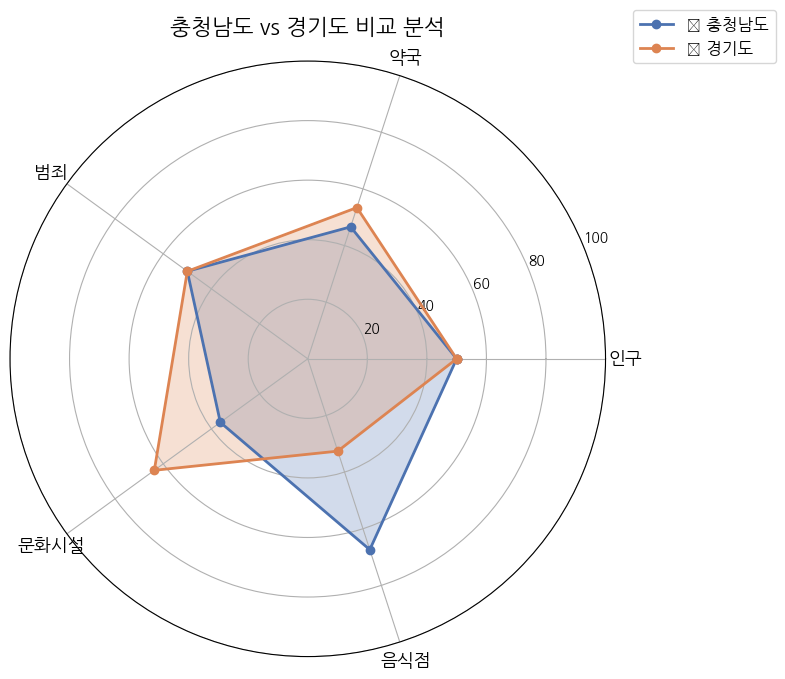

✅ Radar Chart 완료!


In [14]:
#STEP 6: Radar Chart

N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

h_scores = scores[MY_HOMETOWN] + scores[MY_HOMETOWN][:1]
b_scores = scores[MY_BASE] + scores[MY_BASE][:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, h_scores, 'o-', linewidth=2,
        color='#4C72B0', label=f'🏠 {MY_HOMETOWN}')
ax.fill(angles, h_scores, alpha=0.25, color='#4C72B0')

ax.plot(angles, b_scores, 'o-', linewidth=2,
        color='#DD8452', label=f'🪖 {MY_BASE}')
ax.fill(angles, b_scores, alpha=0.25, color='#DD8452')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])

plt.title(f'{MY_HOMETOWN} vs {MY_BASE} 비교 분석',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.tight_layout()
plt.savefig('지역비교.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Radar Chart 완료!")

In [15]:
#STEP 7: 최종 결과 요약

print("\n" + "="*45)
print(f"  📊 {MY_HOMETOWN} vs {MY_BASE} 최종 결과")
print("="*45)

for i, label in enumerate(labels):
    h = scores[MY_HOMETOWN][i]
    b = scores[MY_BASE][i]
    winner = MY_HOMETOWN if h >= b else MY_BASE
    print(f"\n[{label}]")
    print(f"  {MY_HOMETOWN:8s}: {'█' * int(h/5)} {h}점")
    print(f"  {MY_BASE:8s}: {'█' * int(b/5)} {b}점")
    print(f"  🏆 우세: {winner}")

h_total = sum(scores[MY_HOMETOWN])
b_total = sum(scores[MY_BASE])
winner = MY_HOMETOWN if h_total >= b_total else MY_BASE
print("\n" + "="*45)
print(f"  총점: {MY_HOMETOWN} {h_total:.1f}점 | {MY_BASE} {b_total:.1f}점")
print(f"  🏆 최종 우세 지역: {winner}")
print("="*45)


  📊 충청남도 vs 경기도 최종 결과

[인구]
  충청남도    : ██████████ 50.0점
  경기도     : ██████████ 50.0점
  🏆 우세: 충청남도

[약국]
  충청남도    : █████████ 46.6점
  경기도     : ██████████ 53.4점
  🏆 우세: 경기도

[범죄]
  충청남도    : ██████████ 50점
  경기도     : ██████████ 50점
  🏆 우세: 충청남도

[문화시설]
  충청남도    : ███████ 36.3점
  경기도     : ████████████ 63.7점
  🏆 우세: 경기도

[음식점]
  충청남도    : █████████████ 67.4점
  경기도     : ██████ 32.6점
  🏆 우세: 충청남도

  총점: 충청남도 250.3점 | 경기도 249.7점
  🏆 최종 우세 지역: 충청남도


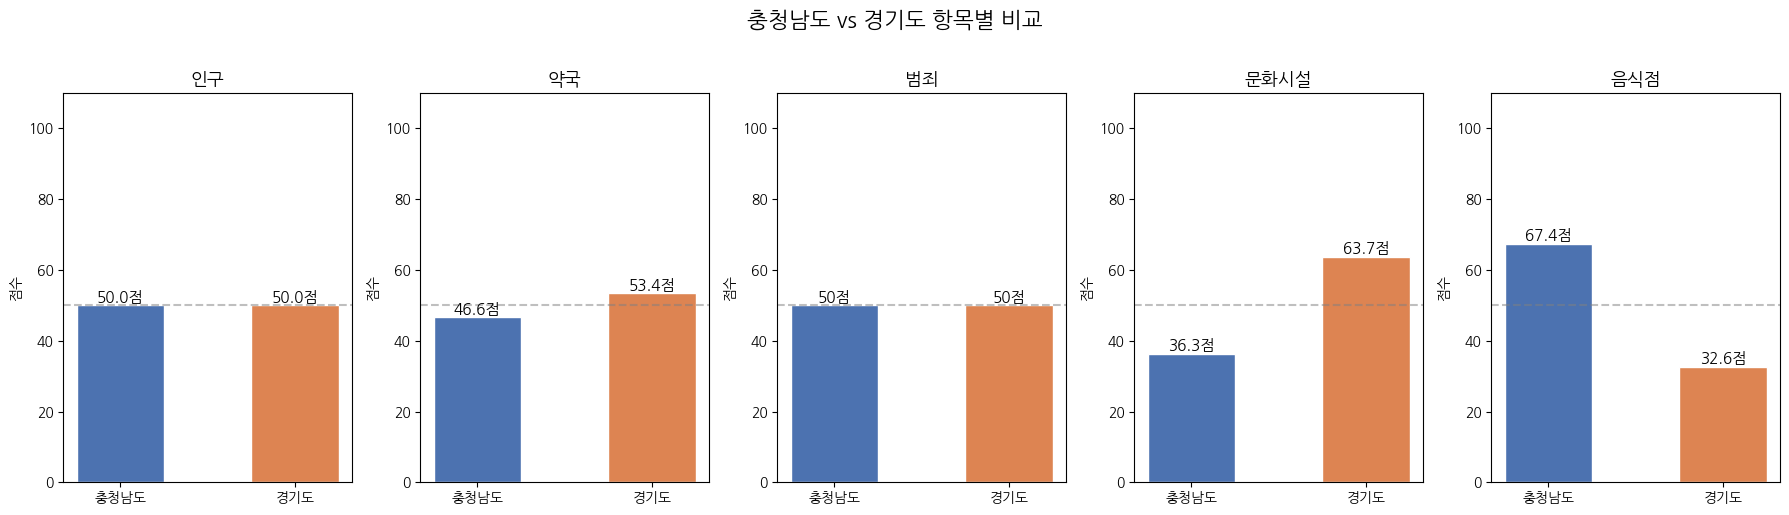

✅ 막대 그래프 완료!


In [16]:
#추가 1: 막대 그래프 비교

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colors = ['#4C72B0', '#DD8452']

for i, label in enumerate(labels):
    h = scores[MY_HOMETOWN][i]
    b = scores[MY_BASE][i]
    bars = axes[i].bar(
        [MY_HOMETOWN, MY_BASE],
        [h, b],
        color=colors,
        width=0.5,
        edgecolor='white'
    )
    # 막대 위에 점수 표시
    for bar, val in zip(bars, [h, b]):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val}점',
            ha='center', fontsize=11, fontweight='bold'
        )
    axes[i].set_title(label, fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, 110)
    axes[i].set_ylabel('점수')
    axes[i].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.suptitle(f'{MY_HOMETOWN} vs {MY_BASE} 항목별 비교',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('항목별_막대그래프.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 막대 그래프 완료!")

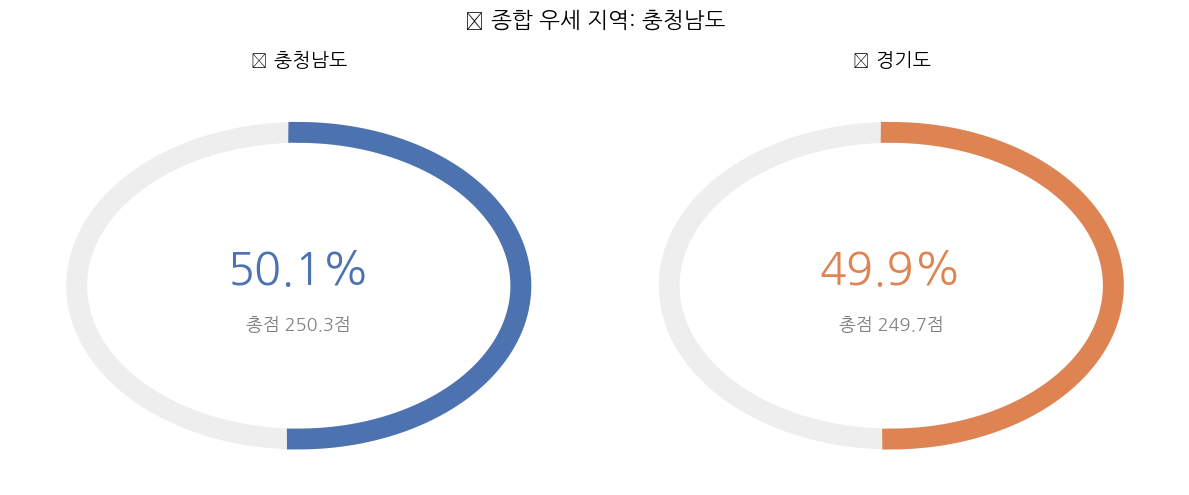

✅ 게이지 차트 완료!


In [17]:
#추가 2: 종합 점수 게이지 차트

h_total = sum(scores[MY_HOMETOWN])
b_total = sum(scores[MY_BASE])
max_total = 500  # 5개 항목 × 100점

h_pct = round((h_total / max_total) * 100, 1)
b_pct = round((b_total / max_total) * 100, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, region, pct, color in zip(
    axes,
    [MY_HOMETOWN, MY_BASE],
    [h_pct, b_pct],
    ['#4C72B0', '#DD8452']
):
    # 배경 원
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta),
            color='#eeeeee', linewidth=15)

    # 점수 원호
    theta_score = np.linspace(np.pi/2, np.pi/2 - (2*np.pi * pct/100), 100)
    ax.plot(np.cos(theta_score), np.sin(theta_score),
            color=color, linewidth=15)

    # 중앙 텍스트
    ax.text(0, 0.1, f'{pct}%',
            ha='center', va='center',
            fontsize=32, fontweight='bold', color=color)
    ax.text(0, -0.25, f'총점 {h_total if region == MY_HOMETOWN else b_total:.1f}점',
            ha='center', va='center', fontsize=13, color='gray')

    emoji = '🏠' if region == MY_HOMETOWN else '🪖'
    ax.set_title(f'{emoji} {region}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.axis('off')

winner = MY_HOMETOWN if h_total >= b_total else MY_BASE
plt.suptitle(f'🏆 종합 우세 지역: {winner}',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('종합점수_게이지.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 게이지 차트 완료!")

In [18]:
#추가 3: 생활 적합도 코멘트 자동 생성

def get_comment(label, h_score, b_score):
    diff = abs(h_score - b_score)
    winner = MY_HOMETOWN if h_score >= b_score else MY_BASE
    loser  = MY_BASE if h_score >= b_score else MY_HOMETOWN

    if diff < 5:
        return f"  ≈ 두 지역 차이 거의 없음 (차이: {diff:.1f}점)"
    elif label == '인구':
        return f"  → {winner}이 더 번화한 지역 (차이: {diff:.1f}점)"
    elif label == '약국':
        return f"  → {winner}이 의료 접근성 우세 (차이: {diff:.1f}점)"
    elif label == '범죄':
        return f"  → {winner}이 더 안전한 지역 (차이: {diff:.1f}점)"
    elif label == '문화시설':
        return f"  → {winner}이 문화생활 더 풍부 (차이: {diff:.1f}점)"
    elif label == '음식점':
        return f"  → {winner}이 먹거리 더 다양 (차이: {diff:.1f}점)"

print("\n" + "="*50)
print(f"  🗒️ {MY_HOMETOWN} vs {MY_BASE} 생활 적합도 분석")
print("="*50)

for i, label in enumerate(labels):
    h = scores[MY_HOMETOWN][i]
    b = scores[MY_BASE][i]
    comment = get_comment(label, h, b)
    print(f"\n[{label}]")
    print(comment)

# 종합 총평
h_total = sum(scores[MY_HOMETOWN])
b_total = sum(scores[MY_BASE])
winner  = MY_HOMETOWN if h_total >= b_total else MY_BASE
loser   = MY_BASE if h_total >= b_total else MY_HOMETOWN
diff    = abs(h_total - b_total)

print("\n" + "="*50)
print(f"\n📋 종합 총평:")
if diff < 10:
    print(f"  두 지역의 생활 환경이 매우 비슷해요!")
    print(f"  어디서나 잘 적응할 수 있는 타입이시네요 💪")
elif diff < 30:
    print(f"  {winner}이 전반적으로 생활 여건이 조금 더 좋아요.")
    print(f"  하지만 {loser}도 나쁘지 않은 환경이에요!")
else:
    print(f"  {winner}이 생활 여건에서 확실히 우세해요!")
    print(f"  전역 후 {winner} 생활이 기대되겠네요 😄")
print("="*50)


  🗒️ 충청남도 vs 경기도 생활 적합도 분석

[인구]
  ≈ 두 지역 차이 거의 없음 (차이: 0.0점)

[약국]
  → 경기도이 의료 접근성 우세 (차이: 6.8점)

[범죄]
  ≈ 두 지역 차이 거의 없음 (차이: 0.0점)

[문화시설]
  → 경기도이 문화생활 더 풍부 (차이: 27.4점)

[음식점]
  → 충청남도이 먹거리 더 다양 (차이: 34.8점)


📋 종합 총평:
  두 지역의 생활 환경이 매우 비슷해요!
  어디서나 잘 적응할 수 있는 타입이시네요 💪


In [19]:
#추가 4: 통계적 요약

import pandas as pd

# 'labels' 변수가 정의되지 않아 오류가 발생했으므로 재정의합니다.
labels = ['인구', '약국', '범죄', '문화시설', '음식점']

print("\n" + "="*50)
print("  📊 변수별 통계적 요약")
print("="*50)

# 점수 데이터를 DataFrame으로 변환
score_df = pd.DataFrame({
    '항목': labels,
    MY_HOMETOWN: scores[MY_HOMETOWN],
    MY_BASE: scores[MY_BASE]
}).set_index('항목')

print("\n[기본 통계량]")
print(score_df.T.describe().round(2))

print("\n[왜도 (Skewness)]")
print(score_df.T.skew().round(3))
print("  → 양수: 오른쪽 꼬리 / 음수: 왼쪽 꼬리 / 0에 가까울수록 균형")


  📊 변수별 통계적 요약

[기본 통계량]
항목       인구     약국    범죄   문화시설    음식점
count   2.0   2.00   2.0   2.00   2.00
mean   50.0  50.00  50.0  50.00  50.00
std     0.0   4.81   0.0  19.37  24.61
min    50.0  46.60  50.0  36.30  32.60
25%    50.0  48.30  50.0  43.15  41.30
50%    50.0  50.00  50.0  50.00  50.00
75%    50.0  51.70  50.0  56.85  58.70
max    50.0  53.40  50.0  63.70  67.40

[왜도 (Skewness)]
항목
인구     NaN
약국     NaN
범죄     NaN
문화시설   NaN
음식점    NaN
dtype: float64
  → 양수: 오른쪽 꼬리 / 음수: 왼쪽 꼬리 / 0에 가까울수록 균형



  🔗 변수 간 상관관계 분석

[상관계수 행렬]
       충청남도    경기도
충청남도  1.000  0.887
경기도   0.887  1.000


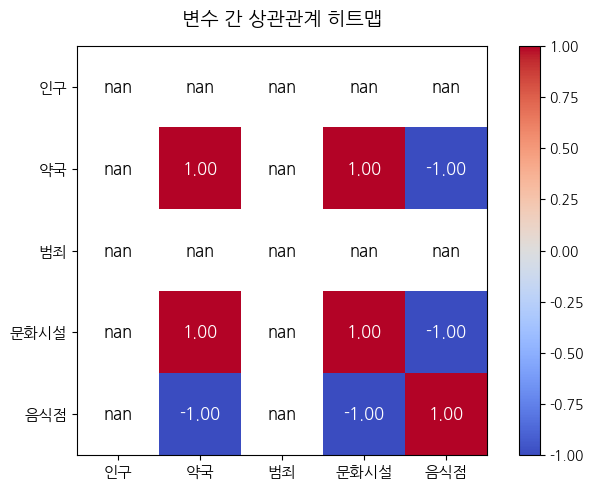

✅ 상관관계 히트맵 완료!


In [20]:
#추가 5: 상관관계 분석

print("\n" + "="*50)
print("  🔗 변수 간 상관관계 분석")
print("="*50)

# 원본 raw 수치로 상관관계 분석
raw_df = pd.DataFrame({
    '항목': labels,
    MY_HOMETOWN: raw[MY_HOMETOWN],
    MY_BASE: raw[MY_BASE]
}).set_index('항목')

# 두 지역 합산 기준으로 변수 간 상관관계 계산
combined_df = pd.DataFrame(raw).T
combined_df.columns = labels

print("\n[상관계수 행렬]")
corr_matrix = combined_df.T.corr()
print(corr_matrix.round(3))

# 상관관계 히트맵 시각화
fig, ax = plt.subplots(figsize=(7, 5))

score_matrix = pd.DataFrame({
    MY_HOMETOWN: scores[MY_HOMETOWN],
    MY_BASE: scores[MY_BASE]
}, index=labels)

corr = score_matrix.T.corr()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

# 셀 안에 수치 표시
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

plt.title('변수 간 상관관계 히트맵', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('상관관계_히트맵.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 상관관계 히트맵 완료!")

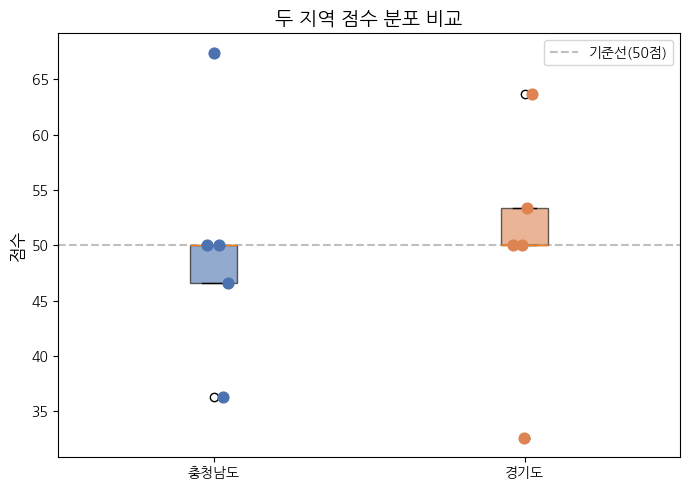

✅ 박스플롯 완료!


In [21]:
#추가 6: 점수 분포 박스플롯

fig, ax = plt.subplots(figsize=(7, 5))

data_to_plot = [scores[MY_HOMETOWN], scores[MY_BASE]]
bp = ax.boxplot(data_to_plot,
                patch_artist=True,
                labels=[MY_HOMETOWN, MY_BASE])

colors = ['#4C72B0', '#DD8452']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 개별 점수 산점도 추가
for i, (region, color) in enumerate(zip([MY_HOMETOWN, MY_BASE], colors), start=1):
    y = scores[region]
    x = [i + np.random.uniform(-0.05, 0.05) for _ in y]
    ax.scatter(x, y, color=color, zorder=5, s=60)

ax.set_ylabel('점수', fontsize=12)
ax.set_title('두 지역 점수 분포 비교', fontsize=14, fontweight='bold')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='기준선(50점)')
ax.legend()
plt.tight_layout()
plt.savefig('점수분포_박스플롯.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 박스플롯 완료!")